In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [3]:
data = pd.read_csv('ParisHousing.csv')

data['House_Age'] = 2026 - data['made']
data['Turnover'] = data['House_Age'] / data['numPrevOwners']
data['Sq_m_per_room'] = data['squareMeters'] / data['numberOfRooms']
data['Sq_m_per_floor'] = data['squareMeters'] / data['floors']
data['basement_ratio'] = data['basement'] / data['squareMeters']
data['attic_ratio'] = data['attic'] / data['squareMeters']
data['garage_ratio'] = data['garage'] / data['squareMeters']

features = [col for col in data.columns if col not in ['price', 'made', 'cityCode']]
X = data[features].values
y = data['price'].values

In [4]:
data = data.drop(['made', 'numberOfRooms', 'numPrevOwners', 'cityCode'], axis=1)
print(data.head(5))

   squareMeters  hasYard  hasPool  floors  cityPartRange  isNewBuilt  \
0         75523        0        1      63              3           0   
1         80771        1        1      98              8           1   
2         55712        0        1      19              6           0   
3         32316        0        0       6             10           0   
4         70429        1        1      90              3           1   

   hasStormProtector  basement  attic  garage  hasStorageRoom  hasGuestRoom  \
0                  1      4313   9005     956               0             7   
1                  0      3653   2436     128               1             2   
2                  0      2937   8852     135               1             9   
3                  1       659   7141     359               0             3   
4                  0      8435   2429     292               1             4   

       price  House_Age  Turnover  Sq_m_per_room  Sq_m_per_floor  \
0  7559081.5         21 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_scaled)
y_pred_lr_scaled = lr.predict(X_test_scaled)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).ravel()
mae_lr = np.mean(np.abs(y_pred_lr - y_test))
mse_lr = np.mean((y_pred_lr - y_test) ** 2)
print(f'Линейная регрессия: MAE = {mae_lr:.2f}, MSE = {mse_lr:.2f}')

Линейная регрессия: MAE = 1508.63, MSE = 3688520.83


In [39]:
y_train_pred_lr_scaled = lr.predict(X_train_scaled)
y_train_pred_lr = scaler_y.inverse_transform(y_train_pred_lr_scaled.reshape(-1,1)).ravel()
train_mae_lr = np.mean(np.abs(y_train_pred_lr - y_train))

print(f"Linear Regression - Train MAE: {train_mae_lr:.2f}, Test MAE: {mae_lr:.2f}")
print(f"Разница: {mae_lr - train_mae_lr:.2f} евро")

Linear Regression - Train MAE: 1469.97, Test MAE: 1508.63
Разница: 38.66 евро


In [6]:
svr = SVR(kernel='rbf', C=100.0, gamma=0.00001, epsilon=0.0001)
svr.fit(X_train_scaled, y_train_scaled)
y_pred_svr_scaled = svr.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()
mae_svr = np.mean(np.abs(y_pred_svr - y_test))
mse_svr = np.mean((y_pred_svr - y_test) ** 2)
print(f'SVR: MAE = {mae_svr:.2f}, MSE = {mse_svr:.2f}')

SVR: MAE = 1535.18, MSE = 3804788.36


In [40]:
y_train_pred_svr_scaled = svr.predict(X_train_scaled)
y_train_pred_svr = scaler_y.inverse_transform(y_train_pred_svr_scaled.reshape(-1,1)).ravel()
train_mae_svr = np.mean(np.abs(y_train_pred_svr - y_train))

print(f"SVR - Train MAE: {train_mae_svr:.2f}, Test MAE: {mae_svr:.2f}")
print(f"Разница: {mae_svr - train_mae_svr:.2f} евро")

SVR - Train MAE: 1496.54, Test MAE: 1535.18
Разница: 38.64 евро


In [167]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l1_l2(0.0001), input_shape=(X_train.shape[1],)),    
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(0.0001)),       
    layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    verbose=2
)

test_loss_scaled, test_mae_scaled = model.evaluate(X_test_scaled, y_test_scaled, verbose=2)

y_pred_nn_scaled = model.predict(X_test_scaled).ravel()
y_pred_nn = scaler_y.inverse_transform(y_pred_nn_scaled.reshape(-1, 1)).ravel()

mae_nn = np.mean(np.abs(y_pred_nn - y_test))
mse_nn = np.mean((y_pred_nn - y_test) ** 2)
print(f'Нейросеть: MAE = {mae_nn:.2f}, MSE = {mse_nn:.2f}')

Epoch 1/500


c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 - 2s - 8ms/step - loss: 0.6021 - mae: 0.5917 - val_loss: 0.3328 - val_mae: 0.4003
Epoch 2/500
200/200 - 0s - 2ms/step - loss: 0.2129 - mae: 0.2641 - val_loss: 0.1525 - val_mae: 0.1802
Epoch 3/500
200/200 - 0s - 2ms/step - loss: 0.1396 - mae: 0.1581 - val_loss: 0.1312 - val_mae: 0.1414
Epoch 4/500
200/200 - 0s - 2ms/step - loss: 0.1257 - mae: 0.1307 - val_loss: 0.1211 - val_mae: 0.1192
Epoch 5/500
200/200 - 0s - 2ms/step - loss: 0.1177 - mae: 0.1120 - val_loss: 0.1149 - val_mae: 0.1044
Epoch 6/500
200/200 - 0s - 2ms/step - loss: 0.1125 - mae: 0.0994 - val_loss: 0.1108 - val_mae: 0.0944
Epoch 7/500
200/200 - 0s - 2ms/step - loss: 0.1088 - mae: 0.0905 - val_loss: 0.1075 - val_mae: 0.0872
Epoch 8/500
200/200 - 0s - 2ms/step - loss: 0.1060 - mae: 0.0842 - val_loss: 0.1052 - val_mae: 0.0823
Epoch 9/500
200/200 - 0s - 2ms/step - loss: 0.1036 - mae: 0.0794 - val_loss: 0.1034 - val_mae: 0.0789
Epoch 10/500
200/200 - 0s - 2ms/step - loss: 0.1015 - mae: 0.0753 - val_loss: 0.1013 - val_mae

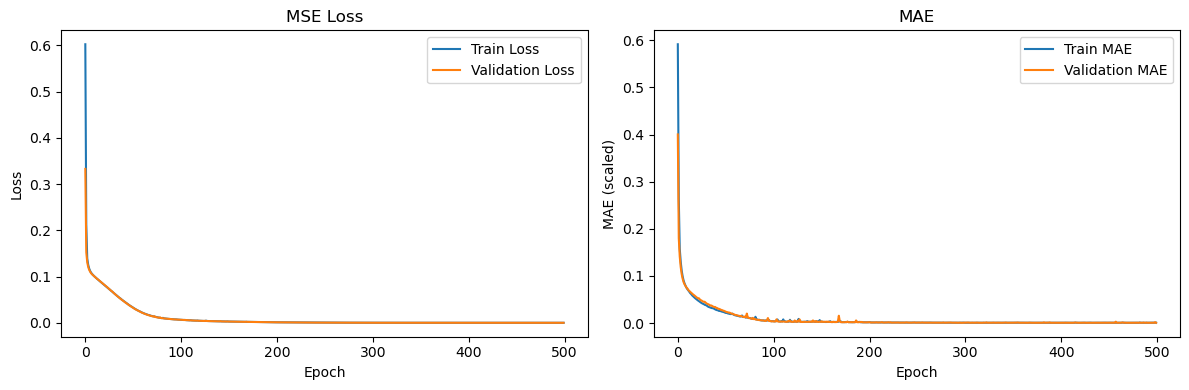

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

In [169]:
y_train_pred_scaled = model.predict(X_train_scaled).ravel()
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1,1)).ravel()
train_mae_orig = np.mean(np.abs(y_train_pred - y_train))

print(f"Neural Network - Train MAE: {train_mae_orig:.2f}, Test MAE: {mae_nn:.2f}")
print(f"Разница: {train_mae_orig - mae_nn:.2f} евро")

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step
Neural Network - Train MAE: 1761.28, Test MAE: 1787.91
Разница: -26.63 евро


In [170]:
print('\nСравнение MAE (в евро):')
print(f'Linear Regression: {mae_lr:.2f}')
print(f'SVR:              {mae_svr:.2f}')
print(f'Neural Network:   {mae_nn:.2f}')


Сравнение MAE (в евро):
Linear Regression: 1508.63
SVR:              1535.18
Neural Network:   1787.91
